# Paper 2 — Notebook 1 of 3
# RQ1: Construct-Validity Audit of the Candidate State Dimensions

## Research question

> **RQ1.** Which subset of the candidate state dimensions
> {I_t, C_t, B_t, M_t, G_t, H_t} can be operationalised from interaction logs with
> demonstrable reliability and convergent validity?

`U_t` is **not** audited as a state component. Estimation uncertainty is a property of the
model's *belief about* the learner, not a coordinate *of* the learner, so it belongs at the
belief level as Σ_t.

## Experimental objective

Apply a pre-registered admission test to each candidate dimension, on all three datasets,
and emit the retained subset as a machine-readable artefact that downstream work can cite.
The audit is deliberately capable of rejecting dimensions the framework proposes.

## What this notebook replaces

`P2_RQ1_assistments_2021.ipynb`, `P2_RQ1_ednet_flat.ipynb`, `P2_RQ1_junyi.ipynb` — three
notebooks whose code differed only in one dataset string, each carrying an embedded copy of
`pcdt_datasets.py` and executing its analysis from a list of string literals via `exec`.

## Runtime

CPU only, no training, a few minutes per dataset. Run this before Notebook 2.

## Pre-registered thresholds (fixed before any data was inspected)

| Criterion | Floor |
|---|---|
| Reliability (Cronbach α, or Spearman-Brown split-half) | ≥ 0.60 |
| Convergent validity \|r\| against an independent mastery signal, warm portion (≥ 5 prior observations) | ≥ 0.30 |
| Simulator recovery against a known latent state | ≥ 0.50 |

**Verdict rule.** `retain` requires reliability **and** convergent validity. Convergent alone
gives `proxy-only`. Simulator recovery alone gives `retain (simulator only)`. Otherwise `reject`.


## RUN IDENTITY

| | |
|---|---|
| **Run ID / folder** | `RQ1__assistments_2021__seed2` |
| **Research question** | RQ1 — construct validity |
| **Dataset** | `assistments_2021` (ASSISTments 2020-21) |
| **Seed** | `20260204` (seed_index 2) |
| **Reads** | nothing — this is a producer |
| **Writes** | `/home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ1__assistments_2021__seed2/` only |
| **Hardware** | CPU |

Self-contained: it loads its own data, runs its own audit, and writes only into its own folder. The seed matters even though nothing is trained — it draws the 20,000-learner subsample, so each seed audits a different sample.

`manifest.json` records the config, environment, every file written with its sha256, and a check that no other run's folder was touched.

In [1]:
# --- locate pcdt_p2.py and p2_runtime.py (package root, one level up) -------------
import os, sys, json, time
_here = os.path.abspath("")
for _c in (_here, os.path.dirname(_here), os.path.join(_here, "..")):
    if os.path.exists(os.path.join(_c, "pcdt_p2.py")):
        sys.path.insert(0, os.path.abspath(_c)); break
import numpy as np, pandas as pd, matplotlib
matplotlib.use("Agg") if os.environ.get("P2_HEADLESS") else None
import matplotlib.pyplot as plt
import pcdt_p2 as P
import p2_runtime as R
print("pcdt_p2   :", P.__file__)
print("p2_runtime:", R.__file__)
# --- AUDIT GUARD (CORRECTIONS.md) -------------------------------------------------
# Refuse to run against the pre-audit library. Without this a stale pcdt_p2.py on the
# path silently reinstates the DKVMN memory-ordering defect and every table below is
# quietly wrong again.
assert hasattr(P.Config(), "dkvmn_legacy_lag"), (
    "the pcdt_p2.py on this path is the PRE-AUDIT copy: it has no dkvmn_legacy_lag "
    "field, so DKVMN still reads its value memory before writing the current "
    "interaction. Replace pcdt_p2.py and p2_runtime.py with the corrected versions.")
assert hasattr(P, "check_alignment"), "corrected pcdt_p2.py is missing check_alignment"

pcdt_p2   : /home/hamed/Downloads/Research/P02/pcdt_p2.py
p2_runtime: /home/hamed/Downloads/Research/P02/p2_runtime.py


In [2]:
# --- locate pcdt_p2.py (package root, one level up from notebooks/) ---
import os, sys, json, time
_HERE = os.getcwd()
for _c in (_HERE, os.path.dirname(_HERE), os.path.join(_HERE, "..")):
    if os.path.exists(os.path.join(_c, "pcdt_p2.py")):
        sys.path.insert(0, os.path.abspath(_c)); break
else:
    raise FileNotFoundError(
        "pcdt_p2.py not found. Run this notebook from inside P02_clean/notebooks/ "
        "with pcdt_p2.py in the parent directory.")

import numpy as np, pandas as pd
import matplotlib
matplotlib.use("Agg") if os.environ.get("P2_HEADLESS") else None
import matplotlib.pyplot as plt
import pcdt_p2 as P

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)
print("pcdt_p2 loaded from:", P.__file__)
print("environment:", P.environment())


pcdt_p2 loaded from: /home/hamed/Downloads/Research/P02/pcdt_p2.py
environment: {'python': '3.13.9', 'platform': 'Linux-7.0.0-28-generic-x86_64-with-glibc2.39', 'numpy': '2.3.5', 'pandas': '2.3.3', 'torch': '2.12.0.dev20260408+cu128', 'cuda': True, 'gpu': 'NVIDIA GeForce RTX 5080'}


In [3]:
# ============================================================================
# CONFIGURATION — GENERATED. This notebook is pinned to ONE dataset and ONE seed.
# Nothing here needs editing. Every path is absolute and explicit.
# ============================================================================
RUN_ID    = "RQ1__assistments_2021__seed2"
DATASET   = "assistments_2021"
SEED_INDEX = 2                      # -> seed 20260204

DATA_ROOT = "/home/hamed/Downloads/Research/dataset"
#   assistments_2021 : {root}/feb_to_apr/plogs.csv  +  {root}/feb_to_apr/pdets.csv
#   ednet_flat       : {root}/EdNet/ednet_kt1_flat.csv
#   junyi            : {root}/junyi/Log_Problem.csv +  {root}/junyi/Info_Content.csv
OUT_ROOT  = "/home/hamed/Downloads/Research/P02/PCDT_P2_runs"

MAX_LEARNERS  = 20_000
MIN_SEQ_LEN   = 10
ALLOW_FIXTURE = False       # True only to smoke-test; the run folder gets a FIXTURE_ prefix

DATASETS = [DATASET]        # this notebook audits exactly one dataset
BASE = P.Config(dataset=DATASET, root=DATA_ROOT, out_root=OUT_ROOT,
                max_learners=MAX_LEARNERS, min_seq_len=MIN_SEQ_LEN,
                seed_index=SEED_INDEX, allow_fixture=ALLOW_FIXTURE)

CTX = R.RunContext(RUN_ID, OUT_ROOT, cfg=P.asdict(BASE),
                   fixture=ALLOW_FIXTURE and not P.dataset_available(DATASET, BASE.paths),
                   description="RQ1 construct-validity audit — ASSISTments 2020-21, seed 20260204")
DIRS = CTX.dirs
for _k, _v in BASE.paths.items():
    print(f"  data {_k:9s} {_v}")

RUN RQ1__assistments_2021__seed2
RQ1 construct-validity audit — ASSISTments 2020-21, seed 20260204
started   2026-08-17 20:00:59   pid 706553
writes to /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ1__assistments_2021__seed2
reads     nothing — this notebook is a producer
concurrent runs detected: RQ1__assistments_2021__seed1
  (parallel execution is supported and expected — see RUN_ORDER.md)
  data plogs     /home/hamed/Downloads/Research/dataset/feb_to_apr/plogs.csv
  data details   /home/hamed/Downloads/Research/dataset/feb_to_apr/pdets.csv


## 2. Dataset loading and validation

Each dataset is normalised to one schema
(`learner_id, item_id, skill_id, start_time, correct, response_time, hint_frac, attempt_count`).
Behavioural richness differs and is deliberately preserved rather than hidden:

| Dataset | hint_frac | attempt_count | → B_t raw material |
|---|---|---|---|
| ASSISTments 2020-21 | present | present | hints + attempts + latency |
| Junyi Academy | present | present | hints + attempts + latency |
| EdNet-KT1 (flat) | absent | absent | latency only |

`validate()` raises rather than warns. Every gate corresponds to a defect that silently
corrupted a result at some point: a degenerate knowledge-component space (Junyi once
collapsed to one KC, which makes C_t's convergent validity 1.000 *by construction*),
non-binary correctness, and unparsed timestamps.

A missing dataset **raises**. The original suite substituted synthetic data and produced a
complete set of tables from it.


In [4]:
DATA, STATS = {}, {}
for ds in DATASETS:
    print("=" * 78); print(ds)
    cfg = P.Config(**{**P.asdict(BASE), "dataset": ds})
    df = P.load_dataset(cfg)
    STATS[ds] = P.validate(df)
    DATA[ds] = df


assistments_2021
[assistments_2021] 15,325 learners | 1,135,067 interactions | 69,229 items | 394 skills | correct 0.669 | median span 48.9 d
        behavioural signals present: ['response_time', 'hint_frac', 'attempt_count']
  OK  15,325 learners | 1,135,067 interactions | 394 KCs
      correct 0.669 | median span 48.9 d | mean span 45.6 d


## 3. Dataset characteristics

Computed from the actual data. Nothing here is quoted from an earlier run.

Report the **mean** span next to the median. A short median with a long mean means a
bimodal population — a substantial long-gap subgroup alongside many one-session learners —
not a dataset unusable for longitudinal work. Quoting the median alone once made EdNet look
unsuitable when 24% of its learners in fact have a ≥ 4-week gap.


In [5]:
rows = []
for ds, df in DATA.items():
    prof, span, maxgap = P.temporal_profile(df)
    s = STATS[ds]
    rows.append(dict(dataset=ds, learners=s["n_learners"], interactions=s["n_interactions"],
                     items=s["n_items"], KCs=s["n_kc"], correct_rate=round(s["correct_rate"], 4),
                     median_span_d=round(s["median_span_days"], 2),
                     mean_span_d=round(s["mean_span_days"], 2),
                     pct_gap_ge_1wk=round(float((maxgap >= 7).mean() * 100), 1),
                     pct_gap_ge_4wk=round(float((maxgap >= 28).mean() * 100), 1),
                     pct_gap_ge_8wk=round(float((maxgap >= 56).mean() * 100), 1),
                     hint=P.DATASET_SPECS[ds]["has_hint"], attempt=P.DATASET_SPECS[ds]["has_attempt"],
                     # AUDIT FIX (CORRECTIONS.md, Finding E): these characteristics belong
                     # to THIS SEED's learner sample, not to the dataset. _subsample_learners
                     # draws max_learners BEFORE the min_seq_len filter and every source
                     # dataset holds more than that, so each seed keeps a different
                     # population and the counts below move with it.
                     seed=cfg.seed, sampled_from_max_learners=cfg.max_learners))
T0 = pd.DataFrame(rows)
print("Table 0. Dataset characteristics for THIS SEED's learner sample.\n")
print(T0.to_string(index=False))
print("\nThese are not fixed properties of the datasets. Seeds 20260202/20260203/20260204 "
      "draw different samples, so learners, interactions, items, KCs and correct-rate all "
      "differ between them. Report Table 1 of the manuscript for the PRIMARY seed and say "
      "so, or report the three side by side — do not present one seed's counts as the "
      "dataset's. Cross-seed agreement elsewhere is correspondingly STRONGER than a "
      "split-only resampling would give, and is worth stating in those terms.")


Table 0. Dataset characteristics for THIS SEED's learner sample.

         dataset  learners  interactions  items  KCs  correct_rate  median_span_d  mean_span_d  pct_gap_ge_1wk  pct_gap_ge_4wk  pct_gap_ge_8wk  hint  attempt     seed  sampled_from_max_learners
assistments_2021     15325       1135067  69229  394        0.6686          48.88        45.62            76.6            20.5             2.5  True     True 20260204                      20000

These are not fixed properties of the datasets. Seeds 20260202/20260203/20260204 draw different samples, so learners, interactions, items, KCs and correct-rate all differ between them. Report Table 1 of the manuscript for the PRIMARY seed and say so, or report the three side by side — do not present one seed's counts as the dataset's. Cross-seed agreement elsewhere is correspondingly STRONGER than a split-only resampling would give, and is worth stating in those terms.


## 4. Proxy construction

Every proxy is computed from history **strictly before** the current response, so no proxy
can see the outcome it is later correlated against.

| Dimension | Proxy |
|---|---|
| C_t cognition | running per-(learner, KC) correctness before the current item |
| B_t behaviour | mean of the available z-scored struggle signals (hint, attempt, latency) |
| M_t metacognition | previous-response latency z, tested against whether a correction follows |
| G_t goals | curricular-progress fraction — no dataset here carries a goal annotation |
| H_t history | recency-weighted prior correctness; judged on **incremental** validity over C_t |
| I_t identity | split-half baseline ability |

The convergent-validity target is a global running correctness signal computed over the
whole history, which is a different statistic from the per-KC C_t proxy.

**B_t is dataset-aware.** An earlier version hardcoded a latency-only proxy — an EdNet
assumption — which wrongly rejected B_t on the two datasets that do carry hint and attempt
columns. The `Proxy set` column of Table 1 records which signals were actually used.


In [6]:
PROX, TRAIT, STRUGGLE = {}, {}, {}
for ds, df in DATA.items():
    PROX[ds], TRAIT[ds], STRUGGLE[ds] = P.build_proxies(df, P.DATASET_SPECS[ds])
    print(f"{ds:18s} struggle-signal B_t: {STRUGGLE[ds]} | "
          f"{len(TRAIT[ds]):,} learners with a split-half ability pair")


assistments_2021   struggle-signal B_t: True | 15,006 learners with a split-half ability pair


## 5. The audit

Two of the reported numbers are boundary cases rather than measurements, and the `note`
column now says so explicitly instead of leaving a referee to work it out:

- **M_t split-half = 0.000** is a floor, not a measurement. The two history halves correlate
  *negatively*; Spearman-Brown is undefined there, so it is clamped to 0.
- **G_t reliability = 1.000** holds by construction. The proxy is a deterministic 0→1 ramp in
  sequence position, so its halves correlate perfectly across learners. Read it as *not a
  measurement*, not as *perfectly reliable*. The verdict is unaffected: G_t fails convergent
  validity anyway.

A third case is a genuine limitation and is flagged, not fixed: **I_t's reliability is
borrowed from C_t's proxy, and its convergent validity is the same statistic as its
simulator recovery** — corr(ability_h1, ability_h2). I_t is therefore validated against its
own stability. See `AUDIT_REPORT.md`, Finding 2.


In [7]:
AUDIT = {}
for ds in DATASETS:
    cfg = P.Config(**{**P.asdict(BASE), "dataset": ds})
    AUDIT[ds] = P.audit_dimensions(PROX[ds], TRAIT[ds], STRUGGLE[ds], cfg, ds)
    print(f"\n{'='*78}\nTable 1 — {ds}\n")
    show = AUDIT[ds][["dimension", "proxy", "alpha", "split_half", "convergent",
                      "sim_recovery", "verdict"]]
    print(show.to_string(index=False, na_rep="n/a"))
    notes = AUDIT[ds][AUDIT[ds].note != ""]
    for r in notes.itertuples():
        print(f"  NOTE [{r.dimension.split()[0]}] {r.note}")



Table 1 — assistments_2021

              dimension                                                                 proxy    alpha  split_half  convergent  sim_recovery verdict
         I_t (identity)                                     split-half baseline-ability trait      n/a    0.839594    0.582151      0.582151  retain
        C_t (cognition)                         running per-KC correctness (mastery estimate)      n/a    0.839594    0.725855           n/a  retain
        B_t (behaviour)                                  hint+attempt+latency struggle signal 0.421161    0.220515   -0.100593           n/a  reject
    M_t (metacognition)                   latency-accuracy coupling (prev_rt_z vs correction)      n/a    0.000000    0.223363      0.223363  reject
            G_t (goals) curricular-progress fraction (no goal annotation in assistments_2021)      n/a    1.000000   -0.008131           n/a  reject
H_t (historical memory) recency-weighted prior correctness; retained only if 

## 6. Results — cross-dataset verdict matrix

In [8]:
mat  = pd.DataFrame({ds: AUDIT[ds].set_index("dimension")["verdict"] for ds in DATASETS})
conv = pd.DataFrame({ds: AUDIT[ds].set_index("dimension")["convergent"] for ds in DATASETS})
print(f"Verdict by dimension — {DATASET}\n")
print(mat.to_string())
print(f"\nConvergent validity (r) — {DATASET}\n")
print(conv.round(3).to_string(na_rep="n/a"))
print(f"\nretained: {list(mat.index[mat[DATASET] == 'retain'])}")
print(f"rejected: {list(mat.index[mat[DATASET] != 'retain'])}")
print("\nWhether these verdicts agree ACROSS datasets and seeds is answered in "
      "SUMMARY__all, which reads every RQ1 run. It is deliberately not answered here: "
      "this notebook sees one dataset at one seed and must not imply otherwise.")

Verdict by dimension — assistments_2021

                        assistments_2021
dimension                               
I_t (identity)                    retain
C_t (cognition)                   retain
B_t (behaviour)                   reject
M_t (metacognition)               reject
G_t (goals)                       reject
H_t (historical memory)           retain

Convergent validity (r) — assistments_2021

                         assistments_2021
dimension                                
I_t (identity)                      0.582
C_t (cognition)                     0.726
B_t (behaviour)                    -0.101
M_t (metacognition)                 0.223
G_t (goals)                        -0.008
H_t (historical memory)             0.912

retained: ['I_t (identity)', 'C_t (cognition)', 'H_t (historical memory)']
rejected: ['B_t (behaviour)', 'M_t (metacognition)', 'G_t (goals)']

Whether these verdicts agree ACROSS datasets and seeds is answered in SUMMARY__all, which reads every RQ1

## 7. Visualisation

One figure, and only because it supports the RQ: it shows each dimension's convergent
validity against the admission threshold, so the size of the pass/fail margin is visible
rather than only the binary verdict.


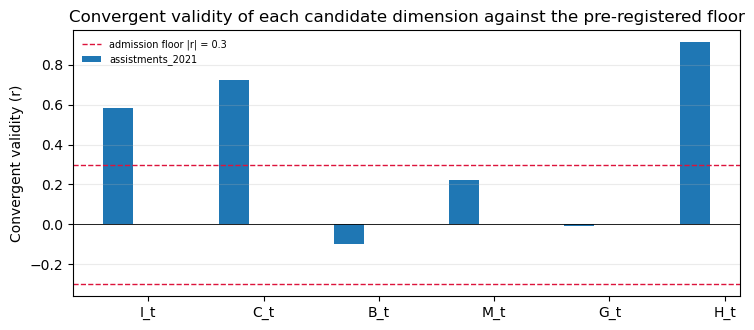

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
dims = list(conv.index); x = np.arange(len(dims)); w = 0.26
for i, ds in enumerate(DATASETS):
    ax.bar(x + (i - 1) * w, conv[ds].values, w, label=ds)
ax.axhline(BASE.convergent_floor, ls="--", c="crimson", lw=1,
           label=f"admission floor |r| = {BASE.convergent_floor}")
ax.axhline(-BASE.convergent_floor, ls="--", c="crimson", lw=1)
ax.axhline(0, c="k", lw=.6)
ax.set_xticks(x); ax.set_xticklabels([d.split()[0] for d in dims])
ax.set_ylabel("Convergent validity (r)")
ax.set_title("Convergent validity of each candidate dimension against the pre-registered floor")
ax.legend(fontsize=7, frameon=False); ax.grid(axis="y", alpha=.25)
fig.tight_layout()

DIRS = DIRS
fig.savefig(os.path.join(DIRS["fig"], "fig1_convergent_validity.png"), dpi=300)
fig.savefig(os.path.join(DIRS["fig"], "fig1_convergent_validity.pdf"))
plt.show()


## 8. RQ1-specific analysis and artefacts

`audited_subset_<dataset>.json` is the machine-readable answer to RQ1 and the artefact
Notebook 2 records alongside its results.

**A dependency that the code does not currently enforce, stated plainly.** The revision
pipeline's `PCDT` class does *not* read this file: it is a single GRU over the interaction
embedding concatenated with a projection of all three behavioural features, with Ψ applied
to the recurrent state. So the audited subset describes which dimensions are *defensible*,
while the trained model's inputs were fixed independently of it. In particular B_t is
rejected on all three datasets yet its signals are fed to the model at every step. See
`AUDIT_REPORT.md`, Finding 4. Nothing here has been changed to paper over that, because
changing the model would change every number in Notebook 2.


In [10]:
SUBSETS = {}
for ds in DATASETS:
    cfg = P.Config(**{**P.asdict(BASE), "dataset": ds})
    d = DIRS
    P.save_tables({f"table1_audit_{ds}": AUDIT[ds]}, d["tab"])
    SUBSETS[ds] = P.write_audited_subset(AUDIT[ds], cfg,
                                         os.path.join(d["out"], f"audited_subset_{ds}.json"))
    print(f"{ds:18s} retained={SUBSETS[ds]['retained']}  "
          f"proxy_only={SUBSETS[ds]['proxy_only']}  -> model_dimensions={SUBSETS[ds]['model_dimensions']}")

P.save_tables({"table0_dataset_characteristics": T0,
               "table1_verdict_matrix": mat.reset_index(),
               "table1_convergent_matrix": conv.reset_index()}, DIRS["tab"])


tables -> /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ1__assistments_2021__seed2/tables: ['table1_audit_assistments_2021']
assistments_2021   retained=['I_t', 'C_t', 'H_t']  proxy_only=[]  -> model_dimensions=['C_t', 'H_t', 'I_t']
tables -> /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ1__assistments_2021__seed2/tables: ['table0_dataset_characteristics', 'table1_convergent_matrix', 'table1_verdict_matrix']


## 9. Conclusion — what RQ1 supports

State the finding at the level the evidence supports, and no further:

- The dimensions that pass the admission test do so **identically on all three datasets**,
  which is a stronger result than a single-dataset audit.
- A rejection is **not** a claim that the construct does not exist. It is a claim that *this
  proxy, on these logs, under these thresholds* does not measure it. B_t is the clearest
  case: prior literature establishes behaviour as a strong **predictor of outcomes**, and
  that is compatible with it failing as a construct-valid **coordinate of a state that
  co-evolves with mastery**. Those are different claims and the audit tests only the second.
- I_t's `retain` verdict means *computational persistence of ability*, not psychological
  identity, and rests on a partly circular measurement (§5).
- All validity here is **internal to the interaction stream**. None of the three datasets
  contains a post-test or any outcome external to the logs, so no dimension is validated
  against an independent educational outcome. This is the study's largest limitation and no
  amount of further computation removes it.


## 10. Reproducibility record

In [11]:
CTX.finalize(extra=dict(
    research_question="RQ1",
    dataset=DATASET, seed=BASE.seed, seed_index=SEED_INDEX,
    dataset_stats=STATS, audited_subset=SUBSETS[DATASET]["model_dimensions"],
    data_paths=BASE.paths))


RUN RQ1__assistments_2021__seed2 — complete
  runtime        0.52 min
  files written  12
  inputs read    0 (0 missing)
  concurrent     RQ1__assistments_2021__seed1 (14 files)
                 ran alongside this one and wrote only into its own folder — expected, not a problem
  isolation      OK — no finished run was modified
  manifest       /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ1__assistments_2021__seed2/manifest.json


{'run_id': 'RQ1__assistments_2021__seed2',
 'description': 'RQ1 construct-validity audit — ASSISTments 2020-21, seed 20260204',
 'status': 'complete',
 'notes': '',
 'fixture': False,
 'started': '2026-08-17 20:00:59',
 'finished': '2026-08-17 20:01:30',
 'runtime_minutes': 0.52,
 'output_dir': '/home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ1__assistments_2021__seed2',
 'environment': {'python': '3.13.9',
  'platform': 'Linux-7.0.0-28-generic-x86_64-with-glibc2.39',
  'numpy': '2.3.5',
  'pandas': '2.3.3',
  'torch': '2.12.0.dev20260408+cu128',
  'sklearn': '1.7.2',
  'scipy': '1.18.0',
  'matplotlib': '3.10.6',
  'cuda': True,
  'gpu': 'NVIDIA GeForce RTX 5080'},
 'config': {'dataset': 'assistments_2021',
  'root': '/home/hamed/Downloads/Research/dataset',
  'out_root': '/home/hamed/Downloads/Research/P02/PCDT_P2_runs',
  'max_learners': 20000,
  'min_seq_len': 10,
  'max_seq_len': 200,
  'train_frac': 0.5,
  'val_frac': 0.1,
  'test_frac': 0.4,
  'split_mode': 'learner',
  '